In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv("train_FD001.txt", sep=r'\s+', header=None, names=cols)
test = pd.read_csv("test_FD001.txt", sep=r'\s+', header=None, names=cols)
rul = pd.read_csv("RUL_FD001.txt", header=None, names=['RUL'])

print("Train shape:", train.shape, "| Engines:", train['unit'].nunique())
print("Test shape:", test.shape, "| Engines:", test['unit'].nunique())
print("RUL shape:", rul.shape)

cycles_per_engine = train.groupby('unit')['cycle'].max()
print("\nCycles-to-failure per engine — describe:")
print(cycles_per_engine.describe())

Train shape: (20631, 26) | Engines: 100
Test shape: (13096, 26) | Engines: 100
RUL shape: (100, 1)

Cycles-to-failure per engine — describe:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [2]:
sensor_cols = [c for c in cols if c.startswith('sensor')]
sensor_std = train[sensor_cols].std().sort_values()
print("Sensor standard deviations (lowest first):")
print(sensor_std)

# These sensors never change at all — carry zero information, drop them
constant_sensors = sensor_std[sensor_std < 1e-6].index.tolist()
print("\nDropping constant sensors:", constant_sensors)

useful_sensors = [c for c in sensor_cols if c not in constant_sensors]

Sensor standard deviations (lowest first):
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

Dropping constant sensors: ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']


In [5]:
train

,unit,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


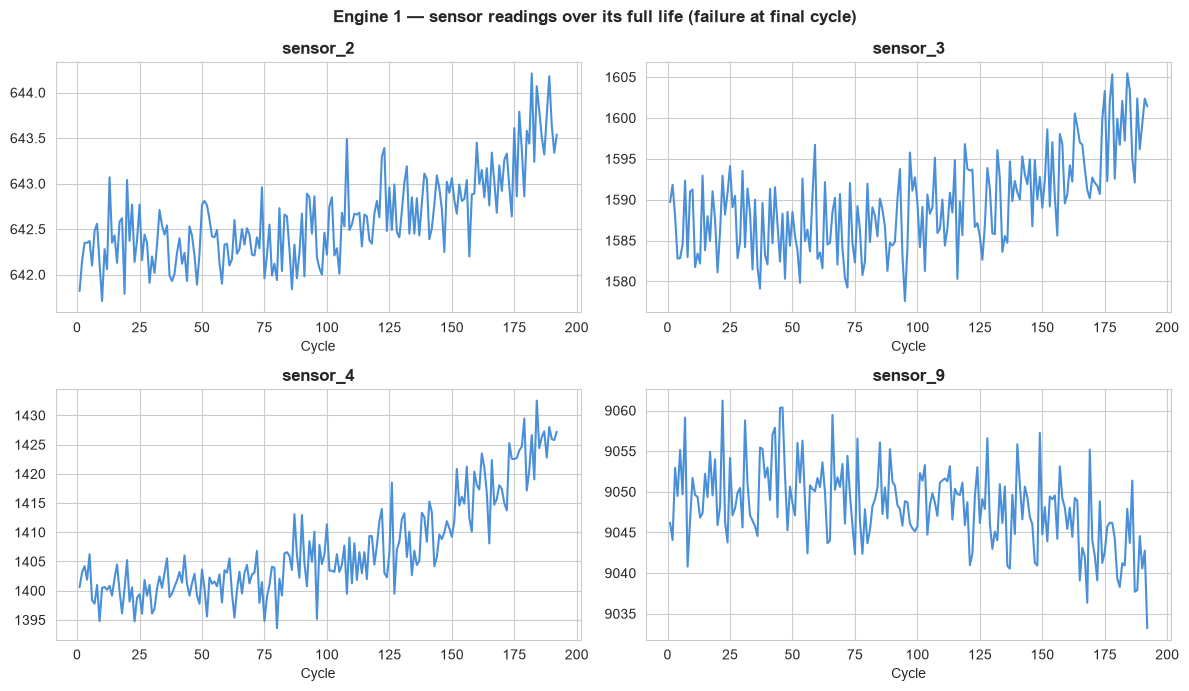

In [7]:
engine1 = train[train['unit'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.flat, ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_9']):
    ax.plot(engine1['cycle'], engine1[s], color='#4A90D9')
    ax.set_title(s, fontweight='bold')
    ax.set_xlabel('Cycle')
plt.suptitle('Engine 1 — sensor readings over its full life (failure at final cycle)', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train[useful_sensors] = scaler.fit_transform(train[useful_sensors])
test[useful_sensors] = scaler.transform(test[useful_sensors])

print("Sensors used:", len(useful_sensors))

Sensors used: 15


In [10]:
train[useful_sensors]

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427
1,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922
2,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423
3,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792
4,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113
20627,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764
20628,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481
20629,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072


In [11]:
SEQ_LEN = 30  # each sequence = 30 consecutive cycles

def create_sequences(df, seq_len, sensors):
    sequences = []
    for unit in df['unit'].unique():
        engine_data = df[df['unit'] == unit][sensors].values
        for i in range(len(engine_data) - seq_len + 1):
            sequences.append(engine_data[i:i+seq_len])
    return np.array(sequences)

X_train_seq = create_sequences(train, SEQ_LEN, useful_sensors)
print("Training sequences shape:", X_train_seq.shape)

Training sequences shape: (17731, 30, 15)


In [12]:
np.random.seed(42)
all_units = train['unit'].unique()
np.random.shuffle(all_units)

n_val_units = 20
val_units = all_units[:n_val_units]
train_units = all_units[n_val_units:]

train_split = train[train['unit'].isin(train_units)]
val_split = train[train['unit'].isin(val_units)]

X_train_final = create_sequences(train_split, SEQ_LEN, useful_sensors)
X_val_final = create_sequences(val_split, SEQ_LEN, useful_sensors)

print("Train sequences:", X_train_final.shape, "| Validation sequences:", X_val_final.shape)

Train sequences: (14241, 30, 15) | Validation sequences: (3490, 30, 15)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

n_features = len(useful_sensors)

autoencoder = Sequential([
    # Encoder: compress the 30-cycle sequence down to a small representation
    LSTM(64, activation='relu', input_shape=(SEQ_LEN, n_features), return_sequences=False),

    # Bridge: repeat that compressed representation once per timestep, so the decoder has something to reconstruct FROM at every step
    RepeatVector(SEQ_LEN),

    # Decoder: expand back out into a full sequence
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(n_features))   # one prediction per timestep, per sensor
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 15)         │           975 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,479 (212.81 KB)

 Trainable params: 54,479 (212.81 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_train_final, X_train_final,   # <- input and target are THE SAME data
    validation_data=(X_val_final, X_val_final),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 0.3620 - val_loss: 0.2977
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2813 - val_loss: 0.2890
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2758 - val_loss: 0.2858
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2727 - val_loss: 0.2823
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2700 - val_loss: 0.2800
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2678 - val_loss: 0.2781
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2664 - val_loss: 0.2772
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2649 - val_loss: 0.2756
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2632 - val_loss: 0.2744
Epoch 10/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2616 - val_loss: 0.2747
Epoch 11/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2604 - val_loss: 0.2708
Epoch 12/50
223/223 ━━━━━━━━━━━━━━━━━━━━

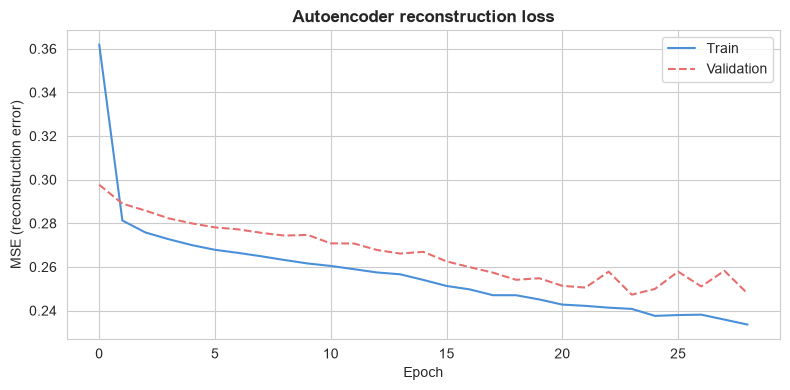

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train', color='#4A90D9')
plt.plot(history.history['val_loss'], label='Validation', color='#E76F6F', linestyle='--')
plt.title('Autoencoder reconstruction loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE (reconstruction error)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
def create_sequences_single_engine(engine_df, seq_len, sensors):
    data = engine_df[sensors].values
    sequences = []
    for i in range(len(data) - seq_len + 1):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

# Pick one test engine to inspect closely first
test_unit_id = test['unit'].unique()[0]
engine_test = test[test['unit'] == test_unit_id]

X_engine_seq = create_sequences_single_engine(engine_test, SEQ_LEN, useful_sensors)
print("Sequences for test engine", test_unit_id, ":", X_engine_seq.shape)

reconstructed = autoencoder.predict(X_engine_seq)
reconstruction_error = np.mean(np.square(X_engine_seq - reconstructed), axis=(1, 2))

print("Reconstruction error range:", reconstruction_error.min(), "to", reconstruction_error.max())

Sequences for test engine 1 : (2, 30, 15)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
Reconstruction error range: 0.17702411714352304 to 0.1791873446423241


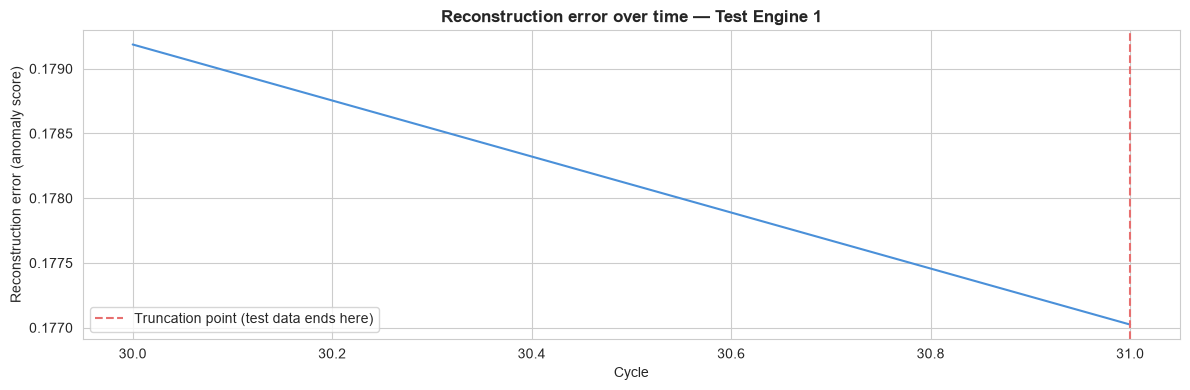

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(range(SEQ_LEN, SEQ_LEN + len(reconstruction_error)), reconstruction_error, color='#4A90D9')
plt.axvline(x=len(engine_test), color='#E76F6F', linestyle='--', label='Truncation point (test data ends here)')
plt.title(f'Reconstruction error over time — Test Engine {test_unit_id}', fontweight='bold')
plt.xlabel('Cycle')
plt.ylabel('Reconstruction error (anomaly score)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
results = []
for unit_id in test['unit'].unique():
    engine_data = test[test['unit'] == unit_id]
    seqs = create_sequences_single_engine(engine_data, SEQ_LEN, useful_sensors)
    if len(seqs) == 0:
        continue
    recon = autoencoder.predict(seqs, verbose=0)
    errors = np.mean(np.square(seqs - recon), axis=(1, 2))
    results.append({'unit': unit_id, 'final_error': errors[-1], 'mean_error': errors.mean(), 'max_error': errors.max()})

results_df = pd.DataFrame(results)
results_df = results_df.merge(rul.reset_index().rename(columns={'index':'unit_idx'}), left_index=True, right_on='unit_idx')

print(results_df[['unit', 'final_error', 'RUL']].corr())
results_df.head(10)

                 unit  final_error       RUL
unit         1.000000     0.149413 -0.043641
final_error  0.149413     1.000000  0.280291
RUL         -0.043641     0.280291  1.000000


,unit,final_error,mean_error,max_error,unit_idx,RUL
0,1,0.177024,0.178106,0.179187,0,112
1,2,0.184356,0.214368,0.231654,1,98
2,3,0.193956,0.196439,0.222571,2,69
3,4,0.194301,0.207035,0.228295,3,82
4,5,0.210166,0.199422,0.224781,4,91
5,6,0.200142,0.220670,0.374833,5,93
6,7,0.209753,0.244650,0.389223,6,91
7,8,0.200971,0.209067,0.265688,7,95
8,9,0.203617,0.207133,0.215194,8,111
9,10,0.203395,0.284071,0.673533,9,96
